 # Pixel-based HSI classification using machine learning

###  1. Import packages

In [1]:
# Importing Libraries
import os
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint
import pandas as pd
import rasterio

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# defining default working directory
os.getcwd()
os.chdir(r"D:\Stephen Adebisi\Machine Learning\Project 1\Project_1\data")



### 2. Load data

In [2]:
file = r"D:\Stephen Adebisi\Machine Learning\Project 1\Project_1\data\mannually_selected_samples_for_model_training_testing.xlsx"

df = pd.read_excel(file, sheet_name='samples')

df


,Labels,B1,B2,B3,B4,B5,B6,B7,B8,B9,...,B260,B261,B262,B263,B264,B265,B266,B267,B268,B269
0,1,0.0000,0.0275,0.0000,0.0239,0.0169,0.0163,0.0201,0.0173,0.0191,...,0.3566,0.2615,0.2816,0.3217,0.3166,0.3243,0.2174,0.2955,0.2988,0.1766
1,1,0.0155,0.0000,0.0000,0.0010,0.0074,0.0119,0.0074,0.0000,0.0132,...,0.2445,0.2094,0.2334,0.2817,0.3163,0.2620,0.2237,0.2189,0.2963,0.1703
2,1,0.0000,0.0000,0.0000,0.0078,0.0124,0.0098,0.0201,0.0202,0.0143,...,0.2240,0.2863,0.2555,0.3071,0.2140,0.3721,0.2471,0.2201,0.4099,0.2637
3,1,0.0000,0.0100,0.0000,0.0000,0.0000,0.0131,0.0000,0.0053,0.0123,...,0.3696,0.4037,0.3329,0.2960,0.3910,0.2463,0.3504,0.2451,0.3714,0.3510
4,1,0.0001,0.0000,0.0040,0.0021,0.0000,0.0168,0.0078,0.0023,0.0058,...,0.2503,0.2942,0.3520,0.3040,0.2519,0.3233,0.2321,0.3367,0.2156,0.2667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1337,5,0.2095,0.2349,0.1612,0.1667,0.1502,0.1439,0.1517,0.1326,0.1353,...,0.2676,0.2722,0.2035,0.2475,0.1897,0.2348,0.1777,0.0979,0.2005,0.3179
1338,5,0.2310,0.1773,0.1538,0.1462,0.1554,0.1516,0.1365,0.1376,0.1417,...,0.1779,0.2794,0.2061,0.2882,0.2248,0.2078,0.1500,0.2049,0.2004,0.1166
1339,5,0.1942,0.2087,0.2016,0.1699,0.1666,0.1418,0.1410,0.1408,0.1484,...,0.2459,0.1744,0.2203,0.1642,0.3145,0.3496,0.1155,0.2686,0.2271,0.1791
1340,5,0.2053,0.1755,0.1684,0.1767,0.1594,0.1418,0.1522,0.1351,0.1352,...,0.2145,0.2390,0.1654,0.2872,0.2262,0.3479,0.1850,0.1190,0.2470,0.1962


### 1.Training and testing data split

In [3]:
# Training and testing data split

# Define y (1st column) and X (all columns from 2nd onward) 
y = df.iloc[:, 0]     # Labels
X = df.iloc[:, 1:]    # Spectral bands

# Stratified 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42,
    shuffle=True
)

#  Print shape of datasets 
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)




X_train shape: (939, 269)
X_test shape: (403, 269)
y_train shape: (939,)
y_test shape: (403,)


## 2. Model building and evaluation

## 2.1. Logistic Regression

In [4]:
# Import the  algorithm from sklearn lib
from sklearn.linear_model import LogisticRegression


In [6]:
# Define the model and train the model

model = LogisticRegression(solver='lbfgs', max_iter=1000)  # Increase max_iter
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [15]:
# Import model evalutoin metrics, and calculate & print out overall accuray, kappa and f-score (testing phase)

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import f1_score


# Evaluate the performance of the model at the Testing phase
y_pred_test = model.predict(X_test)

print('Logistice Regression Model Testing overall accuracy (OA): %.3f' % accuracy_score(y_test, y_pred_test))
print('Model Testing kappa: %.3f' % cohen_kappa_score(y_test, y_pred_test))
print('Model Testing f-score: %.3f' % f1_score(y_test, y_pred_test, average='weighted'))

cm_testing = confusion_matrix(y_test, y_pred_test)
print(cm_testing)



Logistice Regression Model Testing overall accuracy (OA): 0.980
Model Testing kappa: 0.971
Model Testing f-score: 0.980
[[156   0   0   0   0]
 [  0 150   0   0   1]
 [  0   0  21   3   1]
 [  0   0   0  57   1]
 [  0   1   1   0  11]]


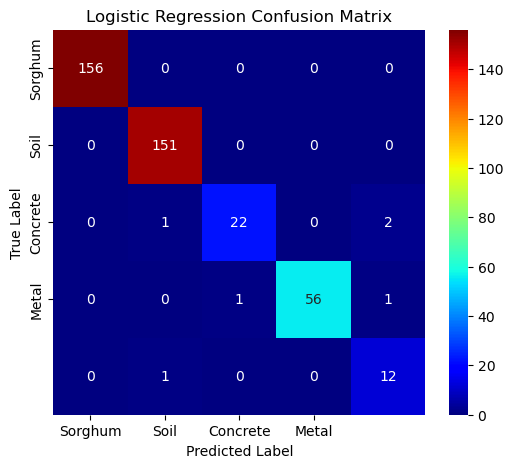

In [11]:
# Plot confusion matrix with value annotations (testing phase)

import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(cm_testing,
            annot=True,
            fmt="d",
            cmap="jet",
            xticklabels=["Sorghum", "Soil", "Concrete", "Metal"],
            yticklabels=["Sorghum", "Soil", "Concrete", "Metal"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix")

plt.show()


### 2.2. Decision Tree (DT)

In [12]:
# Import the  algorithm from sklearn lib
from sklearn.tree import DecisionTreeClassifier


In [13]:
# Define the model and train the model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)


DecisionTreeClassifier()

In [16]:
# Import model evalutoin metrics, and calculate & print out overall accuray, kappa and f-score (testing phase)

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import f1_score


# Evaluate the performance of the model at the Testing phase
y_pred_test = model.predict(X_test)

print('Decision Tree Model Testing overall accuracy (OA): %.3f' % accuracy_score(y_test, y_pred_test))
print('Model Testing kappa: %.3f' % cohen_kappa_score(y_test, y_pred_test))
print('Model Testing f-score: %.3f' % f1_score(y_test, y_pred_test, average='weighted'))

cm_testing = confusion_matrix(y_test, y_pred_test)
print(cm_testing)


Decision Tree Model Testing overall accuracy (OA): 0.980
Model Testing kappa: 0.971
Model Testing f-score: 0.980
[[156   0   0   0   0]
 [  0 150   0   0   1]
 [  0   0  21   3   1]
 [  0   0   0  57   1]
 [  0   1   1   0  11]]


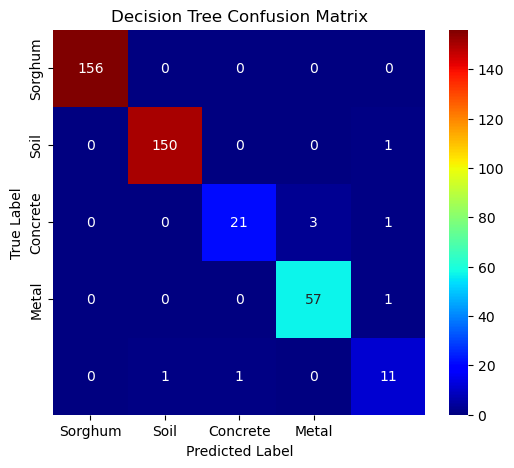

In [17]:
# Plot confusion matrix with value annotations (testing phase)
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(cm_testing,
            annot=True,
            fmt="d",
            cmap="jet",
            xticklabels=["Sorghum", "Soil", "Concrete", "Metal"],
            yticklabels=["Sorghum", "Soil", "Concrete", "Metal"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix")

plt.show()


### 2.3. Radom Forest (RF)

In [18]:
# Import the  algorithm from sklearn lib
from sklearn.ensemble import RandomForestClassifier


In [19]:
# Define the model and train the model
model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

In [20]:
# Import model evalutoin metrics, and calculate & print out overall accuray, kappa and f-score (testing phase)
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import f1_score


# Evaluate the performance of the model at the Testing phase
y_pred_test = model.predict(X_test)

print('Random Forest Model Testing overall accuracy (OA): %.3f' % accuracy_score(y_test, y_pred_test))
print('Model Testing kappa: %.3f' % cohen_kappa_score(y_test, y_pred_test))
print('Model Testing f-score: %.3f' % f1_score(y_test, y_pred_test, average='weighted'))

cm_testing = confusion_matrix(y_test, y_pred_test)
print(cm_testing)


Random Forest Model Testing overall accuracy (OA): 0.988
Model Testing kappa: 0.982
Model Testing f-score: 0.988
[[156   0   0   0   0]
 [  0 151   0   0   0]
 [  0   0  22   1   2]
 [  0   0   1  57   0]
 [  0   1   0   0  12]]


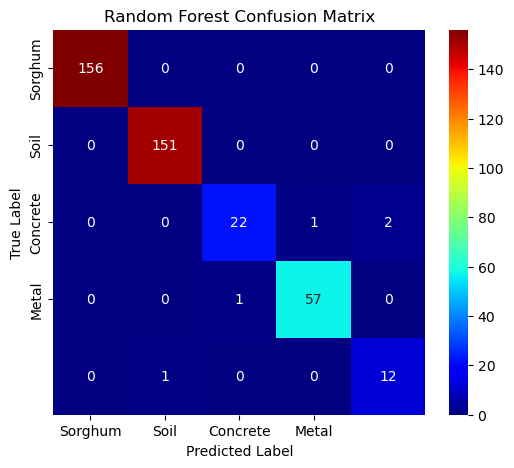

In [21]:
# Plot confusion matrix with value annotations (testing phase)
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(cm_testing,
            annot=True,
            fmt="d",
            cmap="jet",
            xticklabels=["Sorghum", "Soil", "Concrete", "Metal"],
            yticklabels=["Sorghum", "Soil", "Concrete", "Metal"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")

plt.show()



### 2.4. Support Vector Machine (SVM)


In [22]:
# Import the  algorithm from sklearn lib
from sklearn.svm import SVC


In [23]:
# Define the model and train the model
model = SVC()
model.fit(X_train, y_train)


SVC()

In [24]:
# Import model evalutoin metrics, and calculate & print out overall accuray, kappa and f1-score (testing phase)
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import f1_score


# Evaluate the performance of the model at the Testing phase
y_pred_test = model.predict(X_test)

print('SVM Model Testing overall accuracy (OA): %.3f' % accuracy_score(y_test, y_pred_test))
print('Model Testing kappa: %.3f' % cohen_kappa_score(y_test, y_pred_test))
print('Model Testing f-score: %.3f' % f1_score(y_test, y_pred_test, average='weighted'))

cm_testing = confusion_matrix(y_test, y_pred_test)
print(cm_testing)



SVM Model Testing overall accuracy (OA): 0.990
Model Testing kappa: 0.986
Model Testing f-score: 0.990
[[156   0   0   0   0]
 [  0 151   0   0   0]
 [  0   0  22   0   3]
 [  0   0   1  57   0]
 [  0   0   0   0  13]]


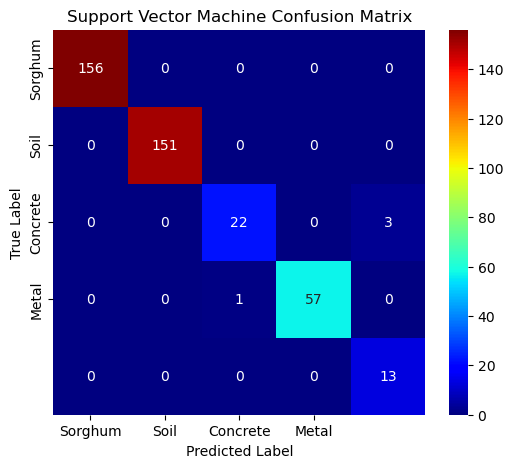

In [25]:
# Plot confusion matrix with value annotations (testing phase)

import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(cm_testing,
            annot=True,
            fmt="d",
            cmap="jet",
            xticklabels=["Sorghum", "Soil", "Concrete", "Metal"],
            yticklabels=["Sorghum", "Soil", "Concrete", "Metal"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Support Vector Machine Confusion Matrix")

plt.show()


## 3. Model Deployment
#### Applying the best model from the above testing results to the hyperspectral imagery to conduct the mapping process!

# Support Vector Machine (SVM) model was deployed


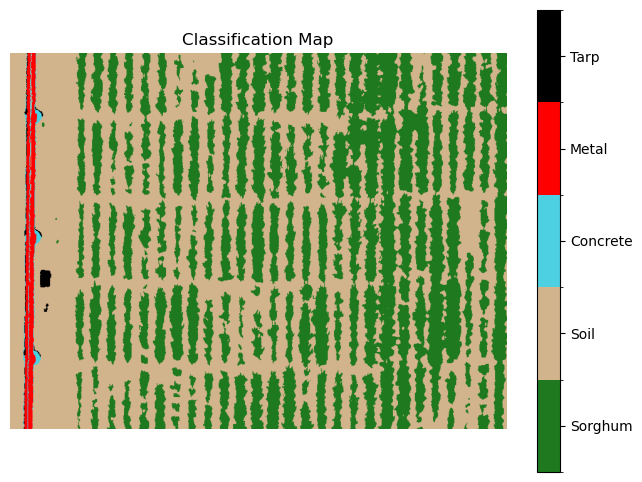

In [32]:

from matplotlib.colors import ListedColormap, BoundaryNorm

#  Read hyperspectral image 
image_file = "HSI_img.tif"

with rasterio.open(image_file) as src:
    hsi = src.read()
    profile = src.profile

bands, rows, cols = hsi.shape

# --- Reshape image for prediction ---
hsi = np.transpose(hsi, (1, 2, 0))
X_image = hsi.reshape(rows * cols, bands)

# If model was trained with DataFrame (avoid warning)
X_image = pd.DataFrame(X_image, columns=X.columns)

# --- Predict full image ---
y_image_pred = model.predict(X_image)

# --- Reshape back to map ---
classified_map = y_image_pred.reshape(rows, cols)



# Plot classification map (Professor Style)


# Define discrete colors in correct class order
# Class order: 1,2,3,4,5
colors = [
    "#1f7a1f",   # 1 Sorghum (green)
    "#D2B48C",   # 2 Soil (tan)
    "#4dd0e1",   # 3 Concrete (cyan)
    "#ff0000",   # 4 Metal (red)
    "#000000"    # 5 Tarp (black)
]

cmap = ListedColormap(colors)

# Create discrete boundaries
bounds = [1, 2, 3, 4, 5, 6]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8,6))
img = plt.imshow(classified_map, cmap=cmap, norm=norm)
plt.title("Classification Map")
plt.axis("off")

# Add discrete colorbar
cbar = plt.colorbar(img, ticks=[1.5, 2.5, 3.5, 4.5, 5.5])
cbar.ax.set_yticklabels(["Sorghum", "Soil", "Concrete", "Metal", "Tarp"])

plt.show()